<h1><center>D208: Multiple Linear Regression Performance Assessment</center></h1>
<br>
<center>Benny Baker</center>
<br>
<center>Department of Information Technology, Western Governor's University</center>
<br>
<center>Dr. Middleton</center>
<br>
<center>March 30, 2024</center>
<br>
<br>
<br>
<br>

## Table of Contents
<ul>
<li><a href="#PartA1">Research Question</a></li>
<li><a href="#PartA2">Objectives and Goals of Analysis</a></li>
<li><a href="#PartB1">Assumptions of a Multiple Regression Model</a></li>
<li><a href="#PartB2">Benefits of Chosen Tools</a></li>
<li><a href="#PartB3">Justification of Multiple Regression</a></li> 
<li><a href="#PartC1">Data Preparation Goals and Necessary Manipulation</a></li> 
<li><a href="#PartC2">Summary Statistics</a></li>
<li><a href="#PartC3">Preparation of Datas</a></li>
<li><a href="#PartC4">Univariate and Bivariate Distributions</a></li> 
<li><a href="#PartC5">Copy of Prepared Data Set</a></li> 
<li><a href="#PartD1">Reduction Justification</a></li>
<li><a href="#PartD2">Limitations of Analysis</a></li>
<li><a href="#PartD3">Reduced Multiple Regression Model</a></li>
<li><a href="#PartE1">Analysis of Multiple Regression Models</a></li>
<li><a href="#PartE2">Model Outputs</a></li>
<li><a href="#PartE3">Model Code</a></li>
<li><a href="#PartF1">Results of Data Analysis</a></li>
<li><a href="#PartF2">Recommended Action</a></li>
<li><a href="#PartG">Panopto Recording</a></li>
<li><a href="#PartH">Code References</a></li>
<li><a href="#PartI">Source References</a></li>
</ul>

<a id='#PartA1'></a>
## A1. Research Question
The research question I want to examine is, "What factors significantly contribute to the Additional Charge amount?"


<a id='PartA2'></a>
## A2. Objectives and Goals of Analysis

What patient factors correlated to Additional Charges? My analysis aims to gain greater insight to determine what patient factors directly correlate to the Additional Charges.

<a id='#PartB1'></a>
## B1. Assumptions of a Multiple Regression Model
Various assumptions must be made to create a multiple linear regression (MLR) model, a statistical technique that uses an explanatory variable to predict the outcome of a response variable (Investopedia, 2024MAR08). These assumptions are:
- Linearity: A linear relationship exists between 
the independent variable, x, and th 
dependent variabl y.e,
- Multicollineartyi: Explanatory variables should not be 
highly correlated with each other.ty
- Independence of 
Observat: The observations are independent and 
randomions
- Homoscedast: The residuals have constant variance at 
every level of x 
Homoscedasticity means that the err r
doesn’t change across all tindependent variable valuesable.icity


<a id='#PartB2'></a>
## B2. Benefits of Chosen Tools 

For this project, I will use Python, a programming language that supports various data science packages/libraries within the IDE JupyterLab, such as:

- pandas allow for the handling of the dataset in something like a large table or spreadsheet
- 
NumPy allows for performing certain mathematical operations or assignment ofspecificn values within the datase
- 
Seaborn ad nmatplotlibib provide graphing functionalt y
SciPy's statsmodeprovidedes several important functionalities for both the multiple regression mo,del such as graphing residuals, as well as for checking problems such multicollinearityity using the variance inflation fac
- or
sklearn's preprocesshelps transformming our ata, when needed


<a id='#PartB3'></a>
## B3. Justification of Multiple Regression

To answer my research question, I need to identify what variables within the medical dataset influence the value of the Additional Charge variable. To estimate the relationship between two or more independent variables and one dependent variable a Multiple Linear Regression (MLR) can be used.

The MLR model will determine how strong the relationship is between the dependent variable (Continuous) and the independent variable.


<a id='#PartC1'></a>

## C1.  Data Cleaning

 My goals for the data cleaning process is to perform the following:

 - Fix Improperly formatted values
   - Use panda's methods `.rename()` and `.zfill()` to fix improperly formatted values.
 - Treat missing values
   - Use panda's methods `.isnull().sum()` to identify if missing values exist.
 - Remove duplicates
   - Use `duplicated()` and `.value_counts()` to remove duplicates
 - Treat outliers
   - Use `describe()` and  `.boxplot(x='col_name', data=df)`



While this data is mostly "clean," there is a one issue involving the variable 'Zip'. Zip codes are being stored as intergers, but zip codes are described as qualitative in the data dictionary. in result, the leading zero's are being truncicated causing data accuracy issues.

To resolve this issue, the 'Zip' variable data type need to be changed to 'str' and filled with leading 0's where the column value has less than 5 characters.

Below, I have re-used some of my code from D206 to amend the datatypes and fill in leading zeros for the Zip column in this dataset.

see code/script attached


In [1]:
import pandas as pd
from pandas.api.types import CategoricalDtype
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import plotnine as p9
from  sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from statsmodels.api import OLS
from statsmodels.regression.linear_model import RegressionResults
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.api import qqplot
from statsmodels.api import add_constant



In [2]:
df = pd.read_csv('./medical_clean.csv', index_col=False, keep_default_na=False)

#Check datatypes and size of dataframe 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 50 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CaseOrder           10000 non-null  int64  
 1   Customer_id         10000 non-null  object 
 2   Interaction         10000 non-null  object 
 3   UID                 10000 non-null  object 
 4   City                10000 non-null  object 
 5   State               10000 non-null  object 
 6   County              10000 non-null  object 
 7   Zip                 10000 non-null  int64  
 8   Lat                 10000 non-null  float64
 9   Lng                 10000 non-null  float64
 10  Population          10000 non-null  int64  
 11  Area                10000 non-null  object 
 12  TimeZone            10000 non-null  object 
 13  Job                 10000 non-null  object 
 14  Children            10000 non-null  int64  
 15  Age                 10000 non-null  int64  
 16  Incom

In [3]:
df.shape

(10000, 50)

In [4]:
if df.isnull().sum().sum() == 0:
    print('No null values found.')
else:
    print('Null values found.')

No null values found.


In [5]:
# Visually inspect dataframe to ensure data loaded as expected and do initial visual exploration
pd.set_option("display.max_columns", None)
df.sort_values(by='Zip').head()

,CaseOrder,Customer_id,Interaction,UID,City,State,County,Zip,Lat,Lng,Population,Area,TimeZone,Job,Children,Age,Income,Marital,Gender,ReAdmis,VitD_levels,Doc_visits,Full_meals_eaten,vitD_supp,Soft_drink,Initial_admin,HighBlood,Stroke,Complication_risk,Overweight,Arthritis,Diabetes,Hyperlipidemia,BackPain,Anxiety,Allergic_rhinitis,Reflux_esophagitis,Asthma,Services,Initial_days,TotalCharge,Additional_charges,Item1,Item2,Item3,Item4,Item5,Item6,Item7,Item8
7945,7946,Z131653,5dff42c2-aa14-4f3d-9eb1-85a45cab1aa1,553f1f10c6dc5bd689e3501763f74b17,Anasco,PR,Añasco,610,18.29032,-67.12243,27073,Rural,America/Puerto_Rico,Product/process development scientist,3,40,75093.64,Married,Female,Yes,19.833860,5,0,2,No,Emergency Admission,Yes,No,Medium,Yes,No,No,No,Yes,Yes,No,Yes,No,Intravenous,62.370210,7821.753000,13676.78000,3,3,3,6,3,3,3,4
1339,1340,P72123,c277e52a-99f5-4fdb-a17d-1ac83b16435a,4d6cceff9888b301d372084b8f809a59,Barceloneta,PR,Barceloneta,617,18.44124,-66.55917,23974,Urban,America/Puerto_Rico,Insurance account manager,1,78,70506.79,Widowed,Male,No,18.079214,6,1,1,No,Emergency Admission,No,Yes,High,No,Yes,No,No,Yes,Yes,No,Yes,No,Blood Work,5.441975,3530.298326,14379.73327,3,3,3,3,3,2,3,3
5813,5814,Q527299,3cca64fe-7391-48e4-b7a3-8e0a72d14561,5fa7855743b0bcec3db78d7a13f2e6b7,Boqueron,PR,Cabo Rojo,622,17.99174,-67.15248,6578,Urban,America/Puerto_Rico,Rural practice surveyor,3,77,55330.42,Widowed,Female,Yes,17.032660,6,3,0,No,Elective Admission,Yes,No,Medium,Yes,Yes,No,Yes,Yes,Yes,Yes,No,No,Blood Work,70.758480,8163.589000,25119.51000,4,4,5,4,4,5,1,4
8932,8933,L546247,de48b132-5a7d-460d-b18e-456623ef80be,2d3614ba9e53d5bda895bef15b6b9e3a,Penuelas,PR,Peñuelas,624,18.06465,-66.71823,22707,Suburban,America/Puerto_Rico,Astronomer,2,25,42550.89,Divorced,Male,No,15.091870,5,0,0,No,Emergency Admission,Yes,No,Medium,No,No,No,Yes,No,No,No,No,Yes,Blood Work,42.099240,6023.843000,8930.92100,3,3,1,5,4,4,4,2
1378,1379,S296435,427c678e-e789-48a2-a9b3-1bd8065b5022,f5f6cdc02dfa19eec3c0098e991963ab,Castaner,PR,Lares,631,18.18555,-66.83327,1568,Rural,America/Puerto_Rico,"Scientist, research (physical sciences)",1,44,21715.44,Separated,Male,No,16.857210,5,1,1,No,Emergency Admission,Yes,No,High,Yes,Yes,No,No,No,Yes,Yes,No,No,MRI,3.274357,3380.766660,15391.88568,3,3,3,5,4,3,2,2


In [6]:
#Clean datatypes up using code from D206 PA. 
#[In-Text Citation: (Nelson, 2023).]

# Convert Zip to string from integer.
df['Zip'] = df['Zip'].astype('str')

# Add leading zeros using zfill()
df['Zip'] = df['Zip'].str.zfill(5)



In [7]:
df.sort_values(by='Zip').head(5)

,CaseOrder,Customer_id,Interaction,UID,City,State,County,Zip,Lat,Lng,Population,Area,TimeZone,Job,Children,Age,Income,Marital,Gender,ReAdmis,VitD_levels,Doc_visits,Full_meals_eaten,vitD_supp,Soft_drink,Initial_admin,HighBlood,Stroke,Complication_risk,Overweight,Arthritis,Diabetes,Hyperlipidemia,BackPain,Anxiety,Allergic_rhinitis,Reflux_esophagitis,Asthma,Services,Initial_days,TotalCharge,Additional_charges,Item1,Item2,Item3,Item4,Item5,Item6,Item7,Item8
7945,7946,Z131653,5dff42c2-aa14-4f3d-9eb1-85a45cab1aa1,553f1f10c6dc5bd689e3501763f74b17,Anasco,PR,Añasco,00610,18.29032,-67.12243,27073,Rural,America/Puerto_Rico,Product/process development scientist,3,40,75093.64,Married,Female,Yes,19.833860,5,0,2,No,Emergency Admission,Yes,No,Medium,Yes,No,No,No,Yes,Yes,No,Yes,No,Intravenous,62.370210,7821.753000,13676.78000,3,3,3,6,3,3,3,4
1339,1340,P72123,c277e52a-99f5-4fdb-a17d-1ac83b16435a,4d6cceff9888b301d372084b8f809a59,Barceloneta,PR,Barceloneta,00617,18.44124,-66.55917,23974,Urban,America/Puerto_Rico,Insurance account manager,1,78,70506.79,Widowed,Male,No,18.079214,6,1,1,No,Emergency Admission,No,Yes,High,No,Yes,No,No,Yes,Yes,No,Yes,No,Blood Work,5.441975,3530.298326,14379.73327,3,3,3,3,3,2,3,3
5813,5814,Q527299,3cca64fe-7391-48e4-b7a3-8e0a72d14561,5fa7855743b0bcec3db78d7a13f2e6b7,Boqueron,PR,Cabo Rojo,00622,17.99174,-67.15248,6578,Urban,America/Puerto_Rico,Rural practice surveyor,3,77,55330.42,Widowed,Female,Yes,17.032660,6,3,0,No,Elective Admission,Yes,No,Medium,Yes,Yes,No,Yes,Yes,Yes,Yes,No,No,Blood Work,70.758480,8163.589000,25119.51000,4,4,5,4,4,5,1,4
8932,8933,L546247,de48b132-5a7d-460d-b18e-456623ef80be,2d3614ba9e53d5bda895bef15b6b9e3a,Penuelas,PR,Peñuelas,00624,18.06465,-66.71823,22707,Suburban,America/Puerto_Rico,Astronomer,2,25,42550.89,Divorced,Male,No,15.091870,5,0,0,No,Emergency Admission,Yes,No,Medium,No,No,No,Yes,No,No,No,No,Yes,Blood Work,42.099240,6023.843000,8930.92100,3,3,1,5,4,4,4,2
1378,1379,S296435,427c678e-e789-48a2-a9b3-1bd8065b5022,f5f6cdc02dfa19eec3c0098e991963ab,Castaner,PR,Lares,00631,18.18555,-66.83327,1568,Rural,America/Puerto_Rico,"Scientist, research (physical sciences)",1,44,21715.44,Separated,Male,No,16.857210,5,1,1,No,Emergency Admission,Yes,No,High,Yes,Yes,No,No,No,Yes,Yes,No,No,MRI,3.274357,3380.766660,15391.88568,3,3,3,5,4,3,2,2


<a id='#PartC2'></a>
## C2. Summary Statistics

The variables that will be used in this analysis are as follows; `Additional Charges` this will be the dependent/target (y) variable in this analysis. `children`, `age`, `income`, `Doc_visits`, `Services`, and `Initial_admin` will be independent/predictor (x) variables. I will also perform summary statistics on using `info()` as well as using `describe()` to get min,max,avg values of the data. I will also use the corr() function in order to create a correlation matrix to see which variables show a linear relationship with the dependent variable.

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 50 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CaseOrder           10000 non-null  int64  
 1   Customer_id         10000 non-null  object 
 2   Interaction         10000 non-null  object 
 3   UID                 10000 non-null  object 
 4   City                10000 non-null  object 
 5   State               10000 non-null  object 
 6   County              10000 non-null  object 
 7   Zip                 10000 non-null  object 
 8   Lat                 10000 non-null  float64
 9   Lng                 10000 non-null  float64
 10  Population          10000 non-null  int64  
 11  Area                10000 non-null  object 
 12  TimeZone            10000 non-null  object 
 13  Job                 10000 non-null  object 
 14  Children            10000 non-null  int64  
 15  Age                 10000 non-null  int64  
 16  Incom

In [9]:
#Creating Quantitative Variable
num_col = df.select_dtypes(exclude = ['object','category'])
print(num_col.columns)

Index(['CaseOrder', 'Lat', 'Lng', 'Population', 'Children', 'Age', 'Income',
       'VitD_levels', 'Doc_visits', 'Full_meals_eaten', 'vitD_supp',
       'Initial_days', 'TotalCharge', 'Additional_charges', 'Item1', 'Item2',
       'Item3', 'Item4', 'Item5', 'Item6', 'Item7', 'Item8'],
      dtype='object')


In [10]:
# Display summary statistics for Quantitative variable
num_col.describe()

,CaseOrder,Lat,Lng,Population,Children,Age,Income,VitD_levels,Doc_visits,Full_meals_eaten,vitD_supp,Initial_days,TotalCharge,Additional_charges,Item1,Item2,Item3,Item4,Item5,Item6,Item7,Item8
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,38.751099,-91.243080,9965.253800,2.097200,53.511700,40490.495160,17.964262,5.012200,1.001400,0.398900,34.455299,5312.172769,12934.528587,3.518800,3.506700,3.511100,3.515100,3.496900,3.522500,3.494000,3.509700
std,2886.89568,5.403085,15.205998,14824.758614,2.163659,20.638538,28521.153293,2.017231,1.045734,1.008117,0.628505,26.309341,2180.393838,6542.601544,1.031966,1.034825,1.032755,1.036282,1.030192,1.032376,1.021405,1.042312
min,1.00000,17.967190,-174.209700,0.000000,0.000000,18.000000,154.080000,9.806483,1.000000,0.000000,0.000000,1.001981,1938.312067,3125.703000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,2500.75000,35.255120,-97.352982,694.750000,0.000000,36.000000,19598.775000,16.626439,4.000000,0.000000,0.000000,7.896215,3179.374015,7986.487755,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000
50%,5000.50000,39.419355,-88.397230,2769.000000,1.000000,53.000000,33768.420000,17.951122,5.000000,1.000000,0.000000,35.836244,5213.952000,11573.977735,4.000000,3.000000,4.000000,4.000000,3.000000,4.000000,3.000000,3.000000
75%,7500.25000,42.044175,-80.438050,13945.000000,3.000000,71.000000,54296.402500,19.347963,6.000000,2.000000,1.000000,61.161020,7459.699750,15626.490000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000
max,10000.00000,70.560990,-65.290170,122814.000000,10.000000,89.000000,207249.100000,26.394449,9.000000,7.000000,5.000000,71.981490,9180.728000,30566.070000,8.000000,7.000000,8.000000,7.000000,7.000000,7.000000,7.000000,7.000000


In [11]:
#Creating Qualitative Subset of dataframe
qualitative_cols = df.select_dtypes(exclude = ['float64', 'int64'])
qualitative_cols= qualitative_cols.drop(columns=['Customer_id','Interaction', 'UID'], axis=1)
print(qualitative_cols.columns)

Index(['City', 'State', 'County', 'Zip', 'Area', 'TimeZone', 'Job', 'Marital',
       'Gender', 'ReAdmis', 'Soft_drink', 'Initial_admin', 'HighBlood',
       'Stroke', 'Complication_risk', 'Overweight', 'Arthritis', 'Diabetes',
       'Hyperlipidemia', 'BackPain', 'Anxiety', 'Allergic_rhinitis',
       'Reflux_esophagitis', 'Asthma', 'Services'],
      dtype='object')


In [12]:
# Create dictionary for unique values and total count for each qualitative variable
unique_count = {}

for col in qualitative_cols.columns:
    unique_value = df[col].unique()
    counts = df[col].value_counts()
    unique_count[col] = (unique_value, counts)

In [13]:
#Display Summary Statistics for Qualitative Variables
line_break = "\n=====================================================\n"

qualitative_dependent_variable = ('Services', 'Initial_admin')

for col in unique_count.fromkeys(qualitative_dependent_variable):
    print(f"{unique_count[col]} {line_break}")

(array(['Blood Work', 'Intravenous', 'CT Scan', 'MRI'], dtype=object), Services
Blood Work     5265
Intravenous    3130
CT Scan        1225
MRI             380
Name: count, dtype: int64) 

(array(['Emergency Admission', 'Elective Admission',
       'Observation Admission'], dtype=object), Initial_admin
Emergency Admission      5060
Elective Admission       2504
Observation Admission    2436
Name: count, dtype: int64) 



Additional Charge (Dependent Variable)
	- `Additional_Charge` has 10000 counts, a minimum value of 3125.70, a maximum value 30566.07, and average of 12934.52 per patient.

Children (Dependent Variable)
	- `Children` has a count of 10000, a minimum value of  0, a maximum value of 10 , and an average of 2 children per patient.

Age (Dependent Variable)
	- `Age` has a count of 10000, a minimum value of 18, a maximum value of 89 , and an average age of 54.
	
income (Dependent Variable)
	- `income` has a count of 10000, a minimum value of  154.10, a maximum value of 207249.10 , and an average of 40490.50 per patient.

Doc_visits (Dependent Variable)
	- `doc_visits` has a count of 10000, a minimum value of  1, a maximum value of 9 , and an average of 5 doctor visits>

</tbody>
</table>can|1225|
|MRI|380|


Services (Independent Variable)
<table style="float: left;">
<tbody>
<tr>
<td>Services</td>
<td>Count of Services</td>
</tr>
<tr>
<td>Blood Work</td>
<td>5265</td>
</tr>
<tr>
<td>Intravenous</td>
<td>3130</td>
</tr>
<tr>
<td>CT Scan</td>
<td>1225</td>
</tr>
<tr>
<td>MRI</td>
<td>380</td>
</tr>
</tbody>
</table>

Intial Admission (Independent Variable)
<table style="float: left;">
<tbody>
<tr>
<td>initial_admin</td>
<td>count of initial_admin</td>
</tr>
<tr>
<td>Emergency Admission</td>
<td>5060</td>
</tr>
<tr>
<td>Elective Admission</td>
<td>2504</td>
</tr>
<tr>
<td>Observation Admission</td>
<td>2436</td>
</tr>
</tbody>
</table>
 Variables</h4>


<a id='#PartC3'></a>
## C3. Visualizations
### Univariate Visualization

array([[<Axes: title={'center': 'Lat'}>, <Axes: title={'center': 'Lng'}>,
        <Axes: title={'center': 'Population'}>,
        <Axes: title={'center': 'Children'}>,
        <Axes: title={'center': 'Age'}>],
       [<Axes: title={'center': 'Income'}>,
        <Axes: title={'center': 'VitD_levels'}>,
        <Axes: title={'center': 'Doc_visits'}>,
        <Axes: title={'center': 'Full_meals_eaten'}>,
        <Axes: title={'center': 'vitD_supp'}>],
       [<Axes: title={'center': 'Initial_days'}>,
        <Axes: title={'center': 'TotalCharge'}>,
        <Axes: title={'center': 'Additional_charges'}>,
        <Axes: title={'center': 'Item1'}>,
        <Axes: title={'center': 'Item2'}>],
       [<Axes: title={'center': 'Item3'}>,
        <Axes: title={'center': 'Item4'}>,
        <Axes: title={'center': 'Item5'}>,
        <Axes: title={'center': 'Item6'}>,
        <Axes: title={'center': 'Item7'}>],
       [<Axes: title={'center': 'Item8'}>, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >

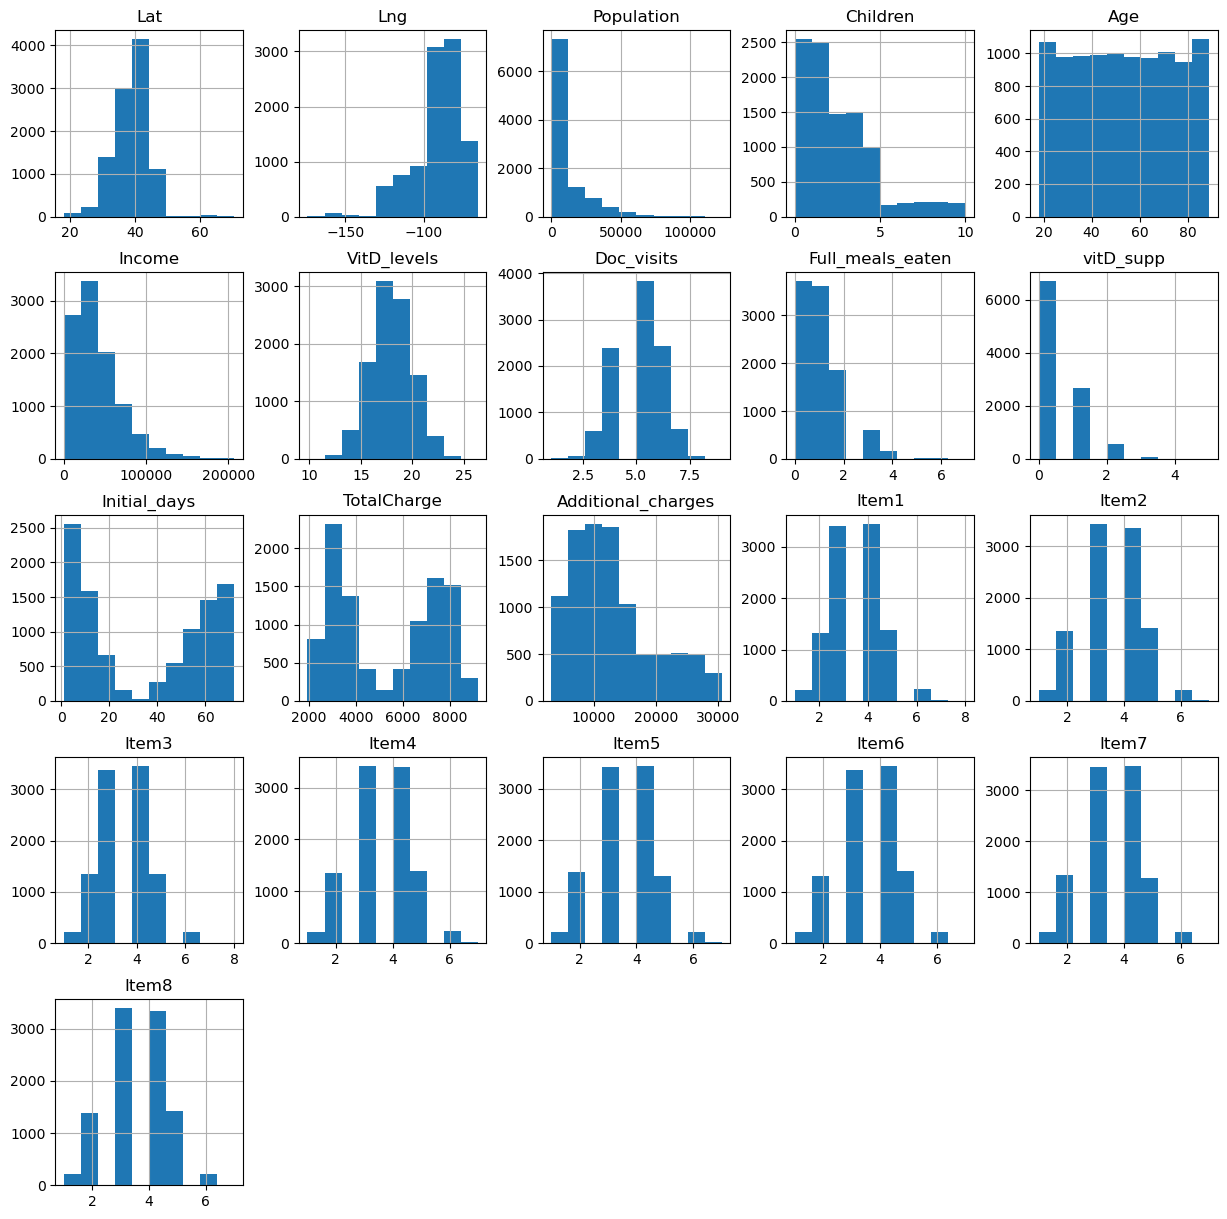

In [14]:
num_col.drop(columns='CaseOrder').hist(figsize=(15,15))

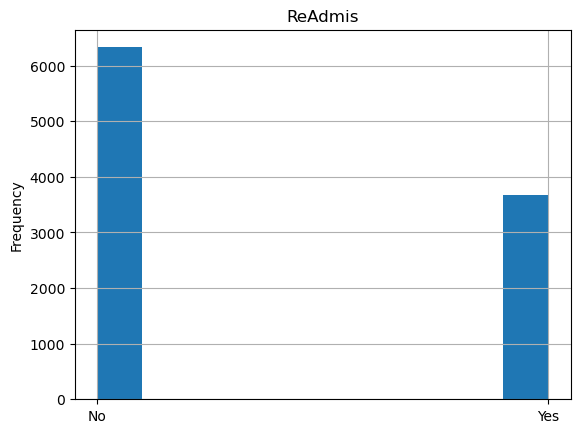

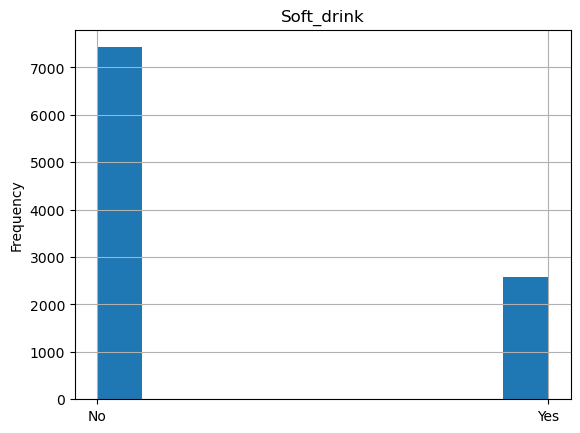

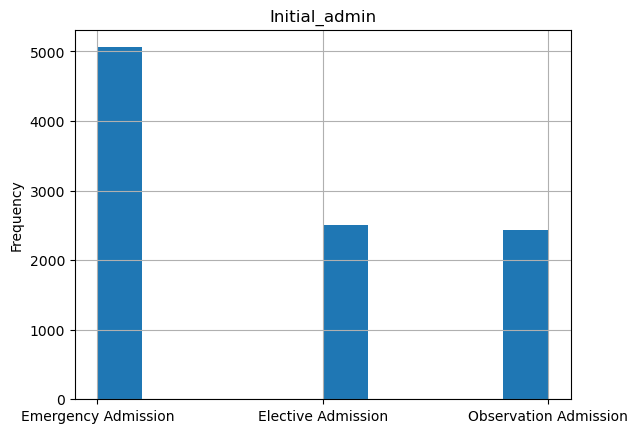

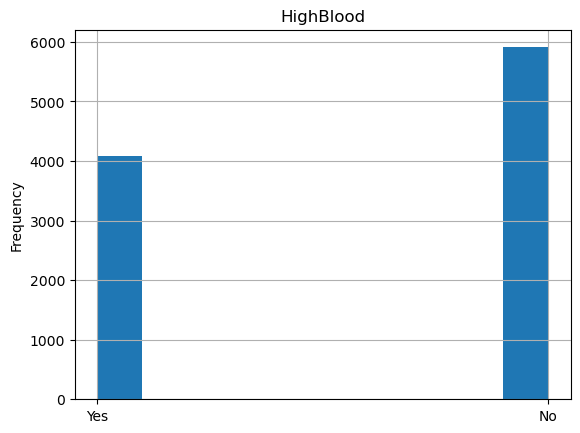

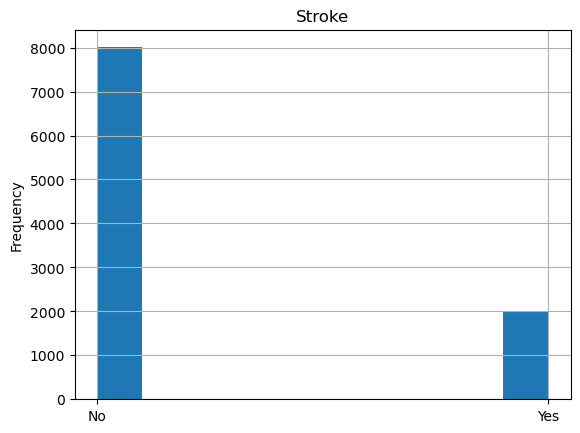

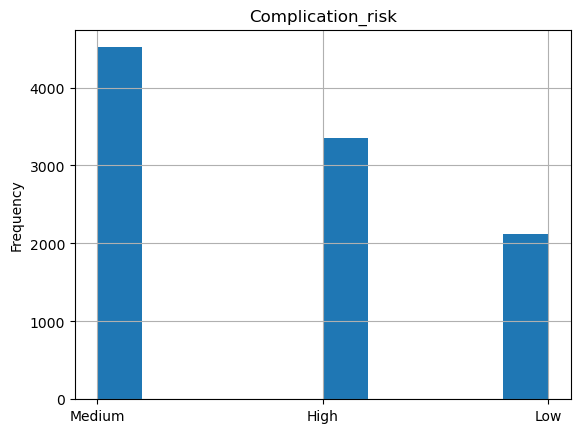

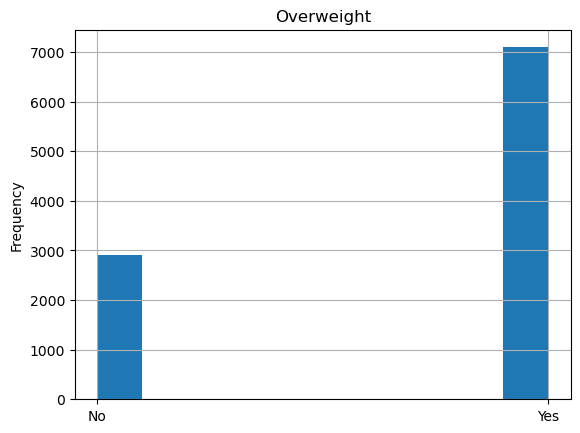

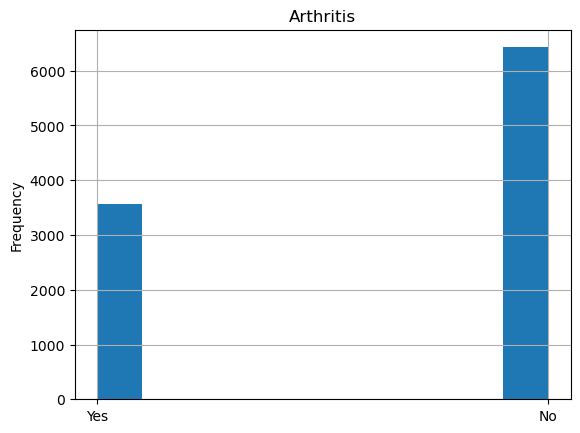

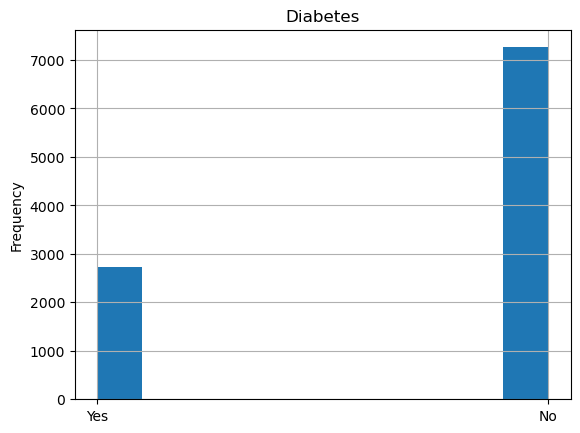

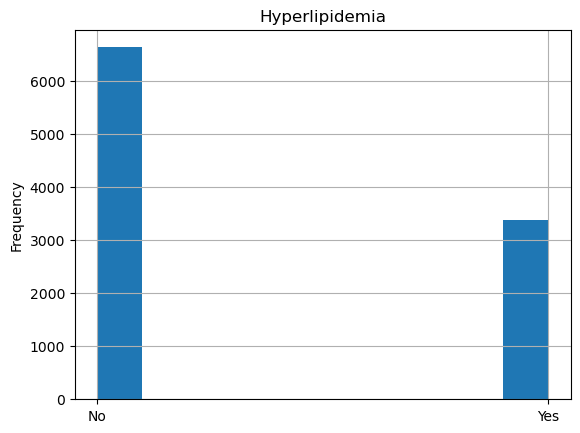

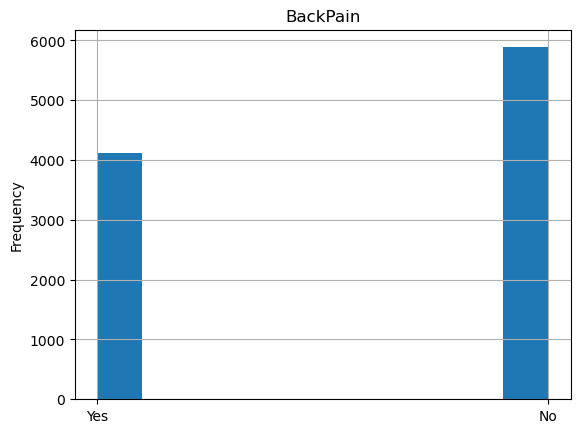

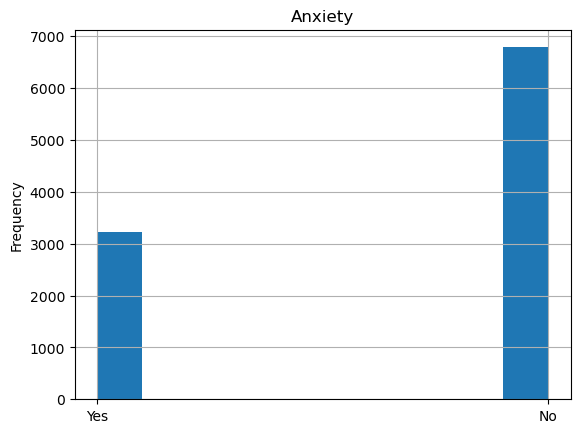

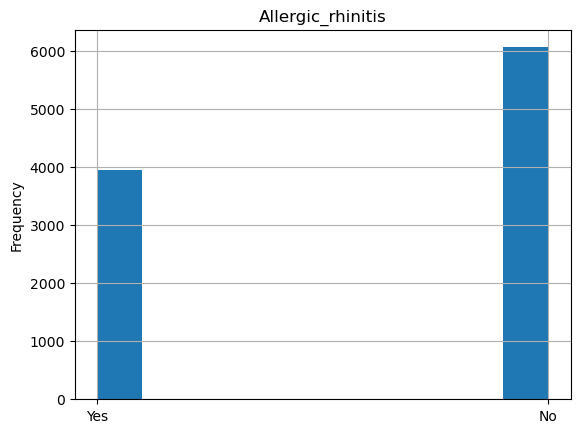

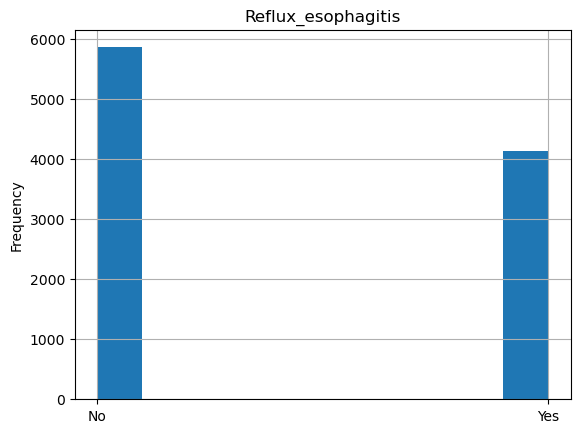

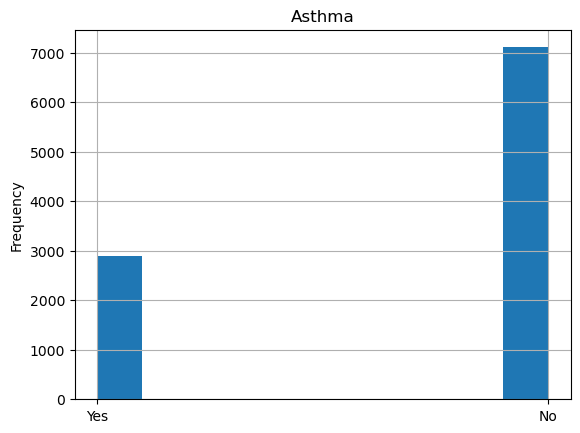

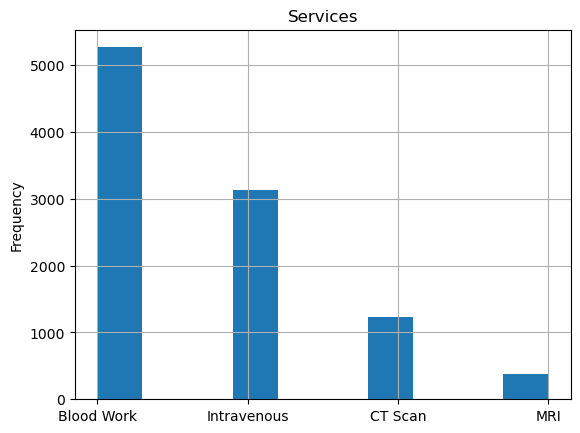

In [15]:
#[In-Text Citation: (GeeksforGeeks, 2022).]
col_to_drop = ['City', 'State', 'County', 'Zip',
       'Area', 'TimeZone', 'Job', 'Marital', 'Gender']

independent_targets_cat = qualitative_cols.drop(columns=col_to_drop)
for independent in independent_targets_cat.columns:
    df[independent].hist()
    plt.title(independent)
    plt.ylabel("Frequency")
    plt.show()

### Bivariate Visualizations

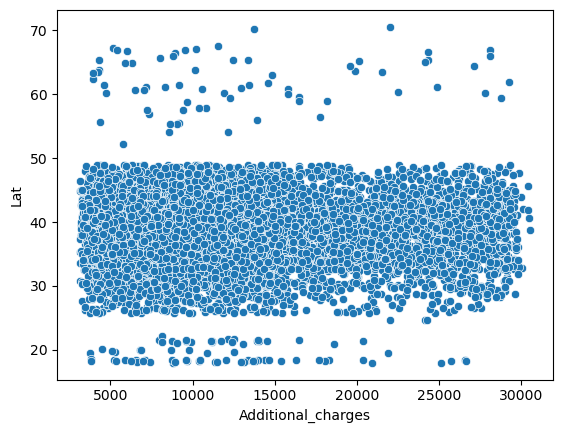

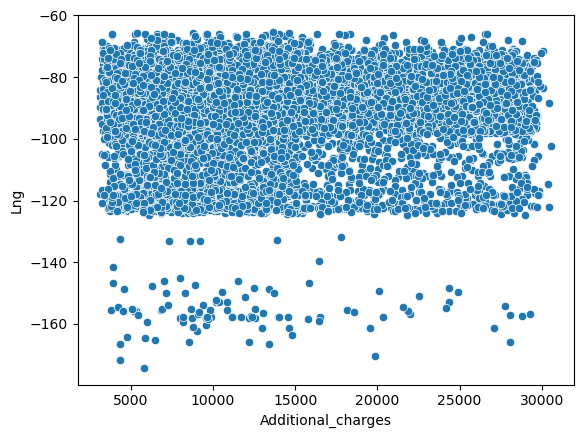

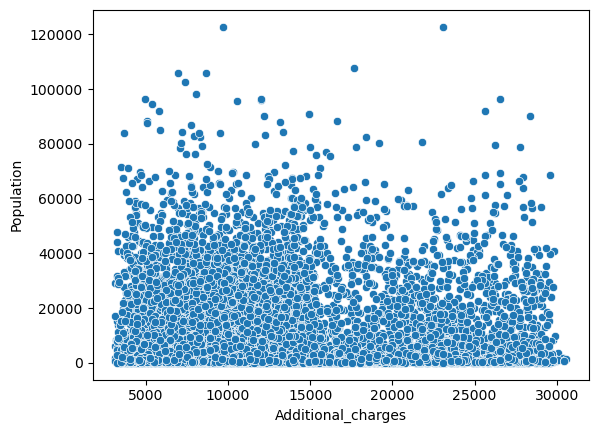

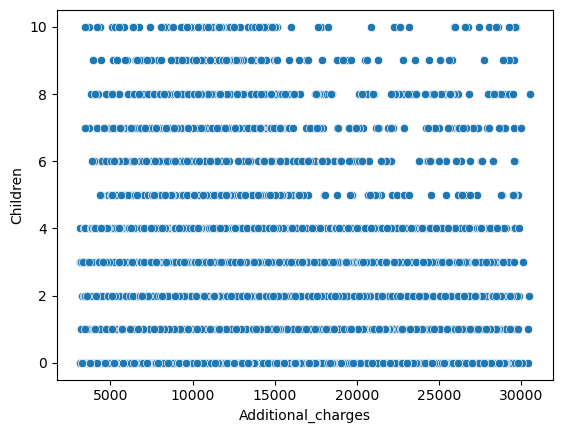

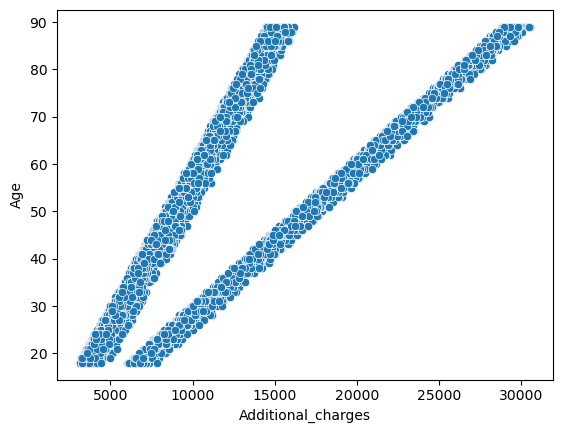

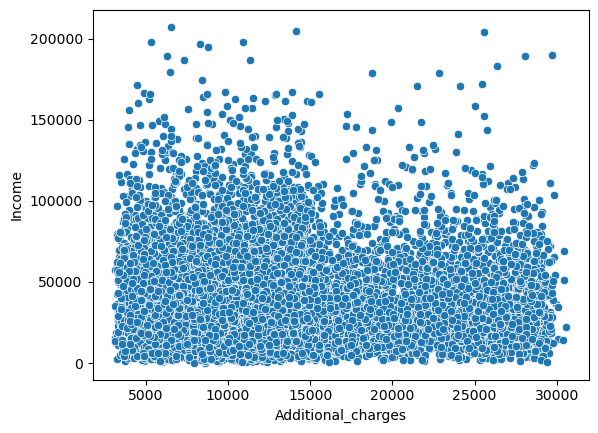

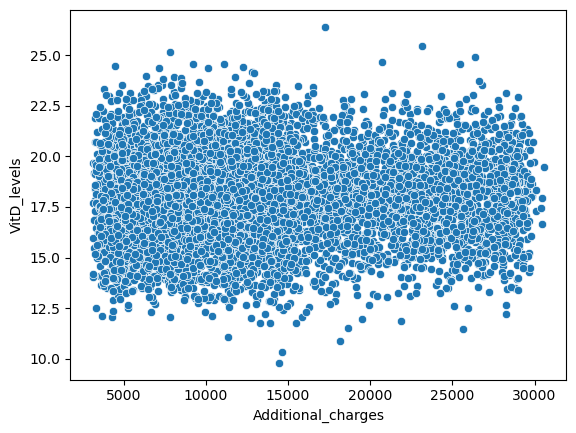

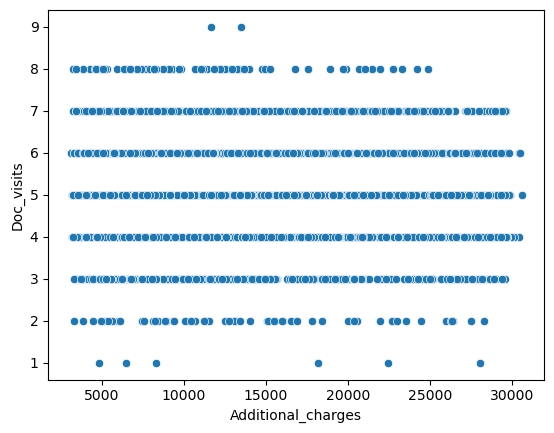

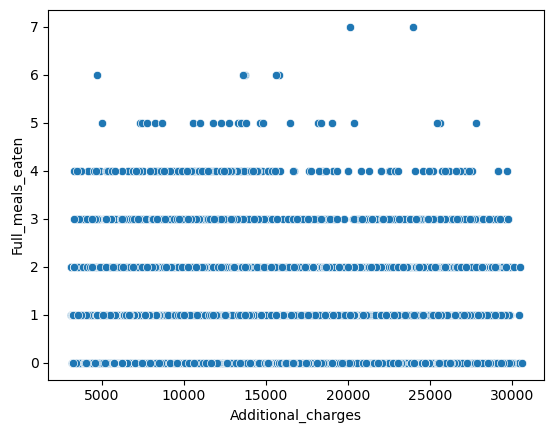

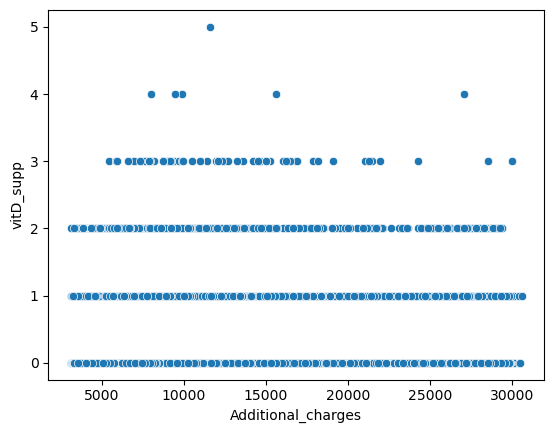

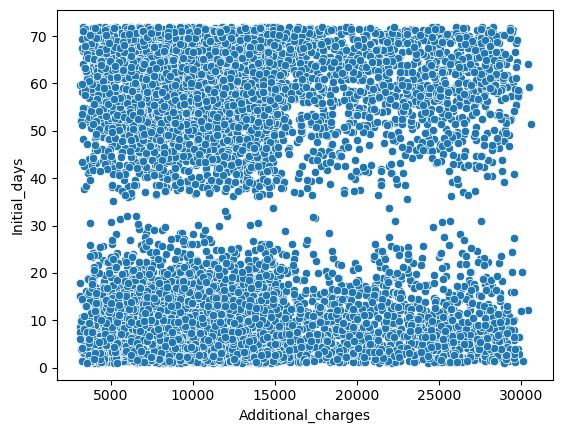

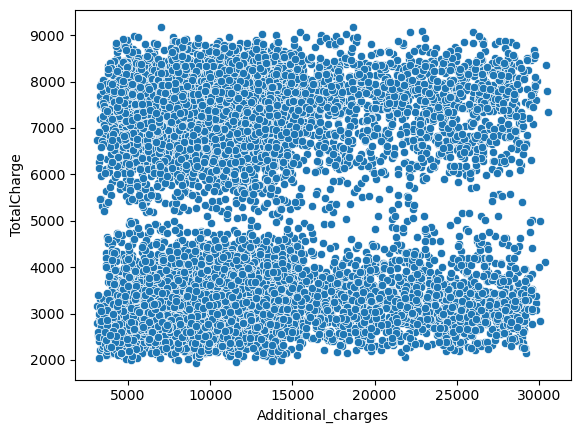

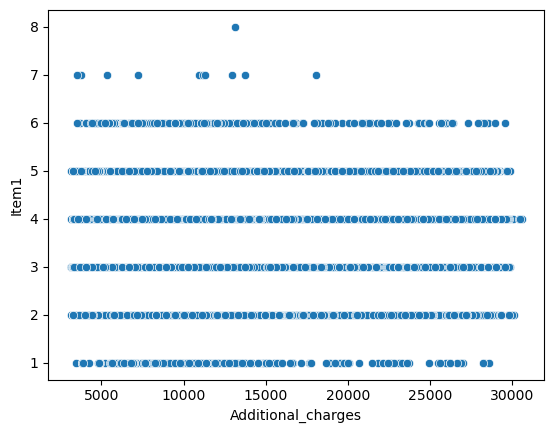

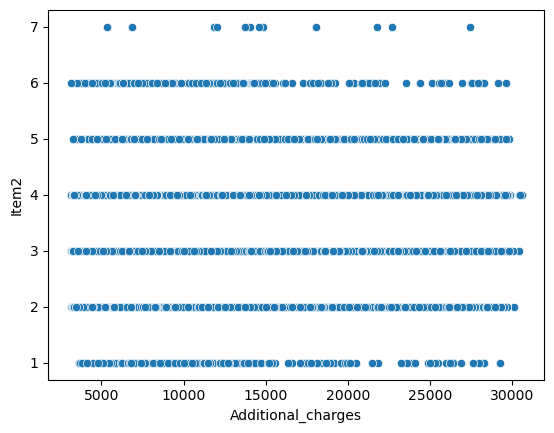

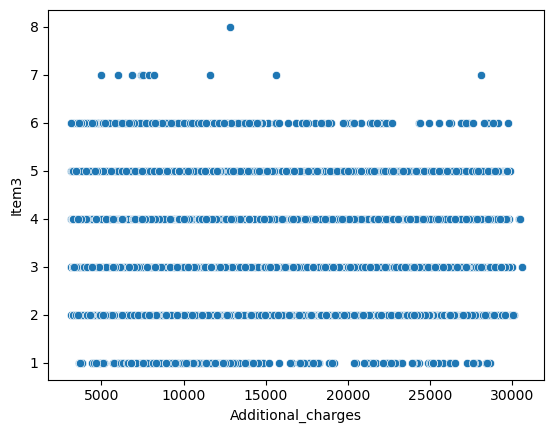

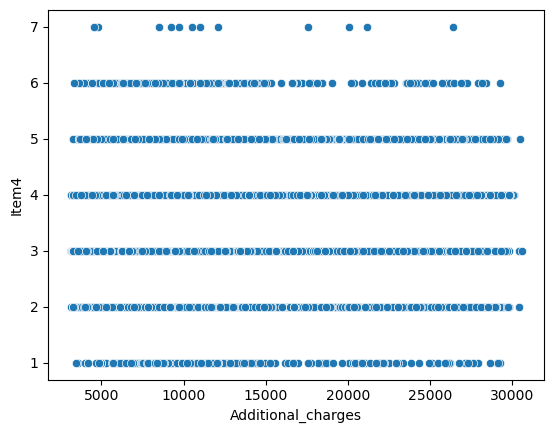

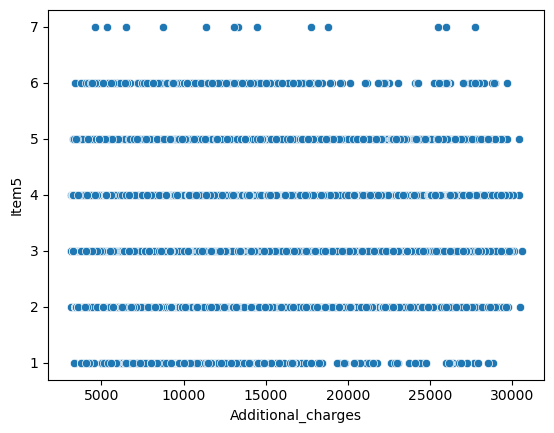

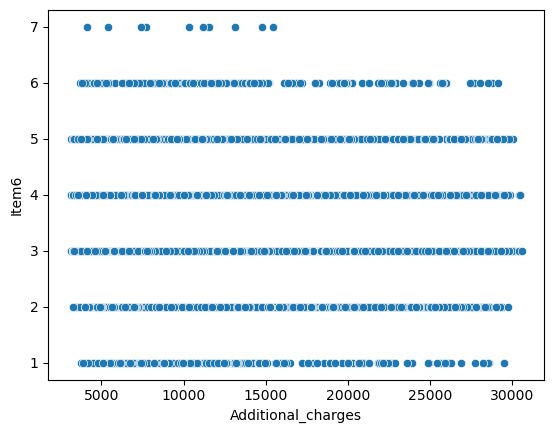

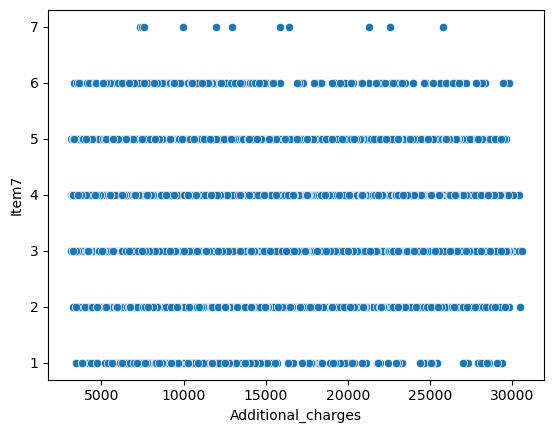

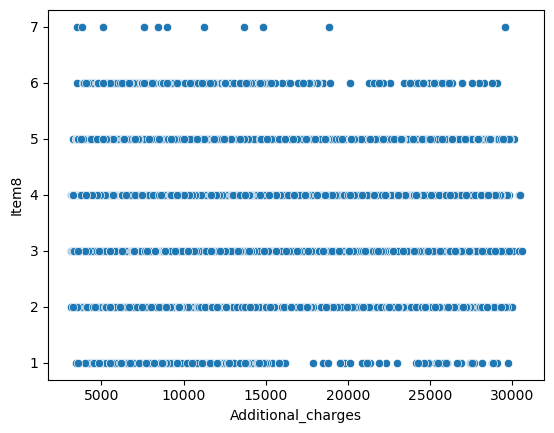

In [16]:
#Bivariate Additional Charge(continuous) Children (continuous)

dependent_target = "Additional_charges"

independent_targets = num_col.drop(columns=dependent_target)
independent_targets = independent_targets.drop(columns='CaseOrder')

for independent in independent_targets.columns:
    sns.scatterplot(x=dependent_target, y=independent, data=df)
    plt.show()

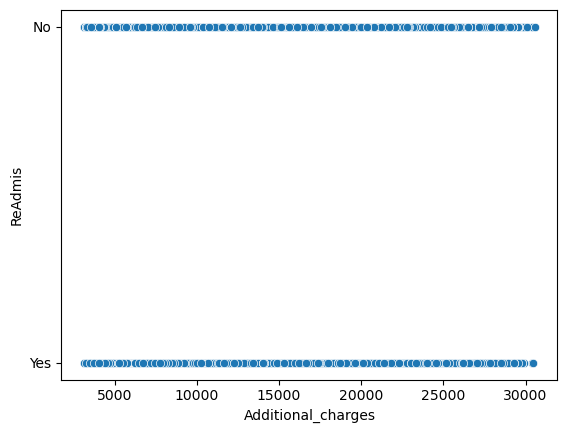

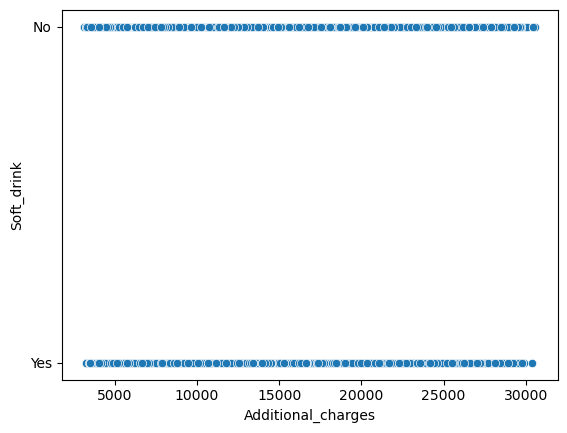

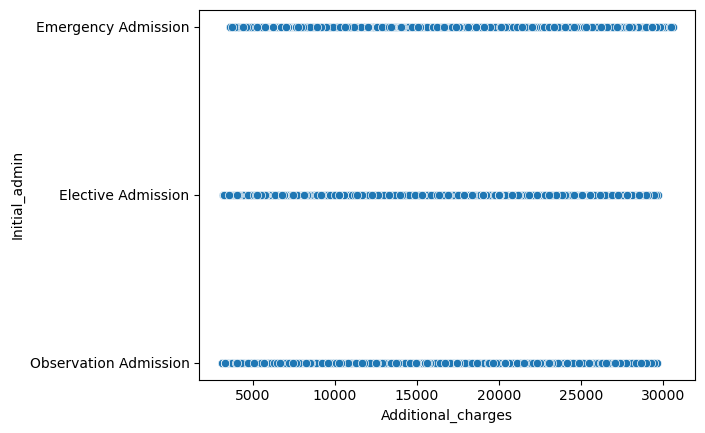

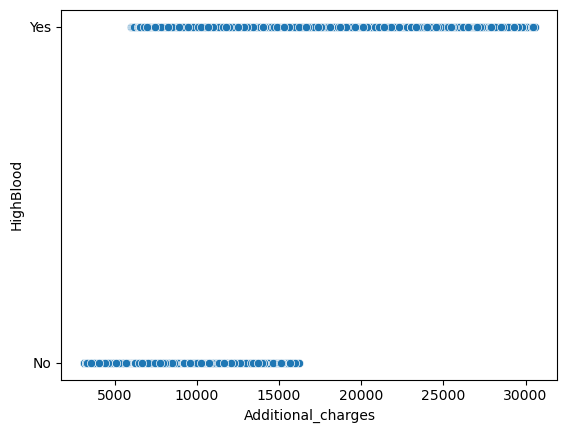

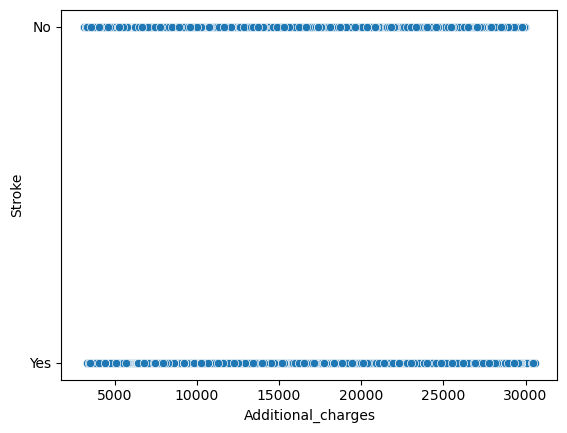

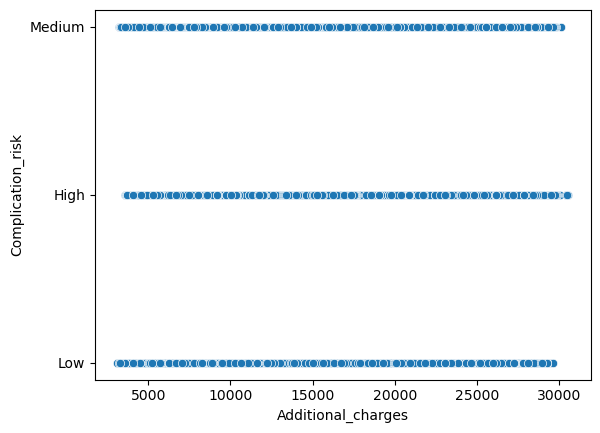

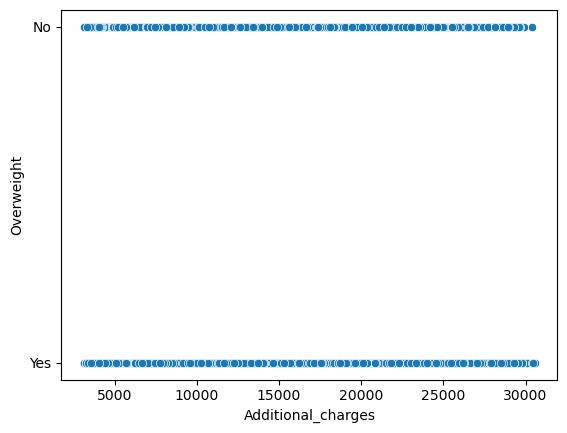

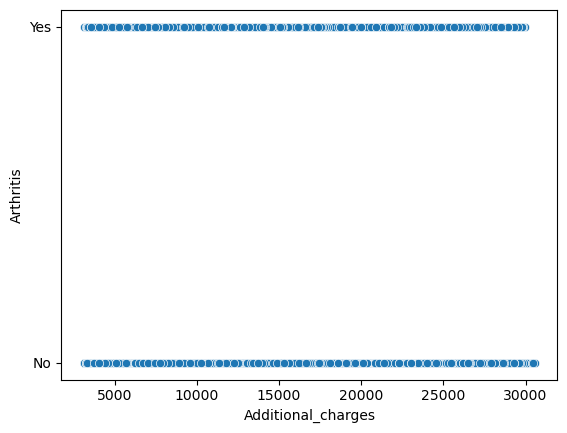

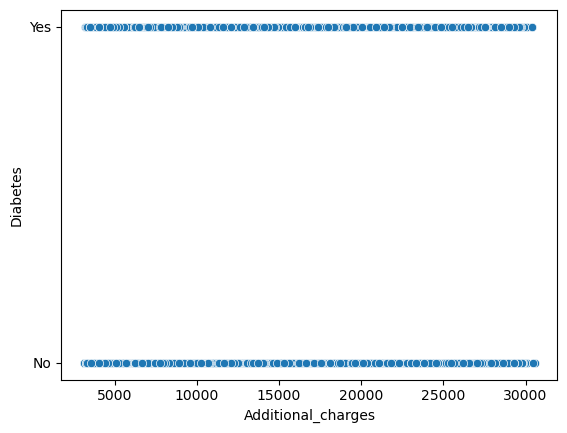

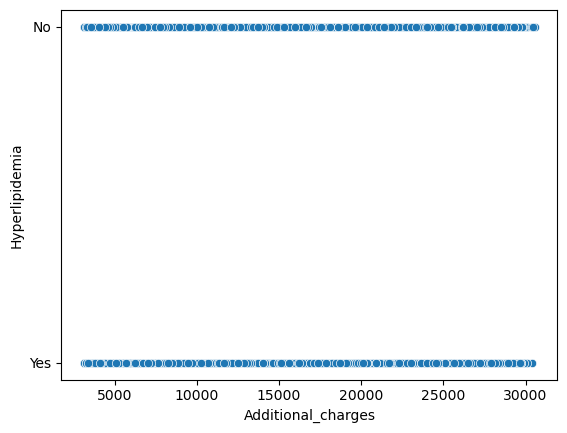

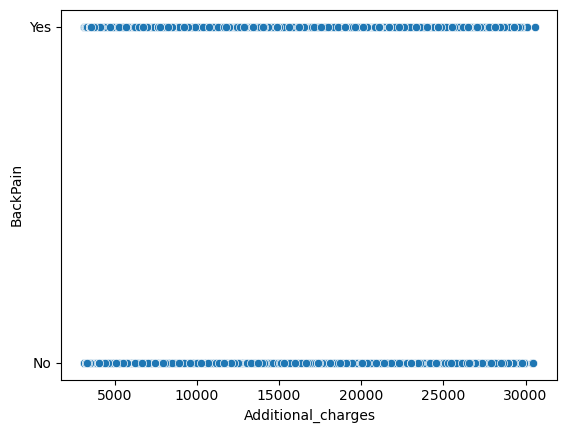

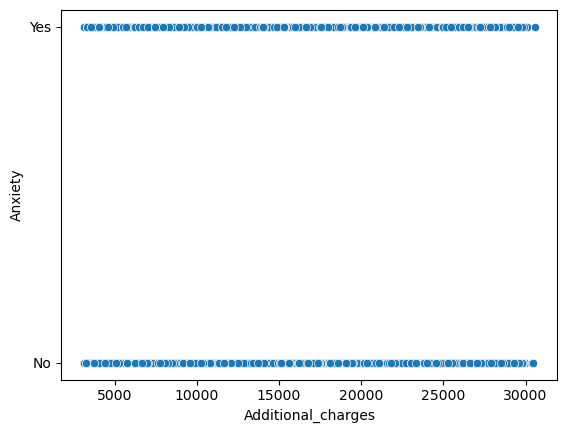

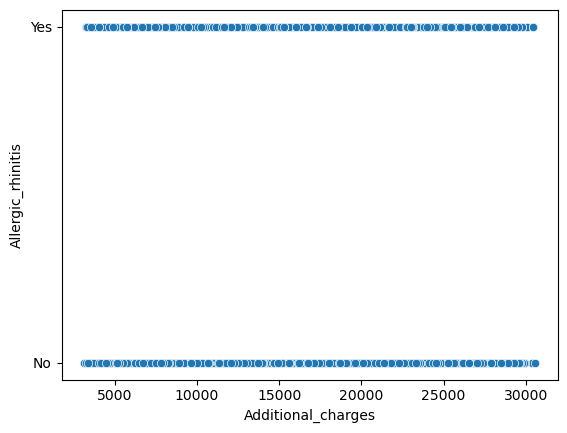

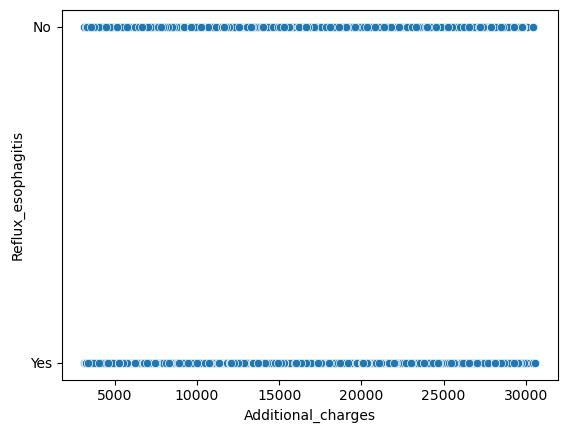

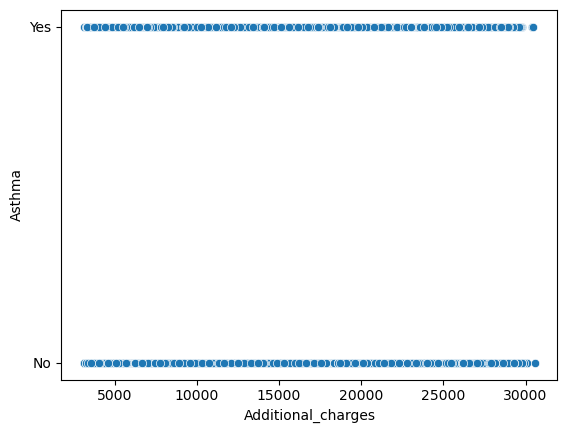

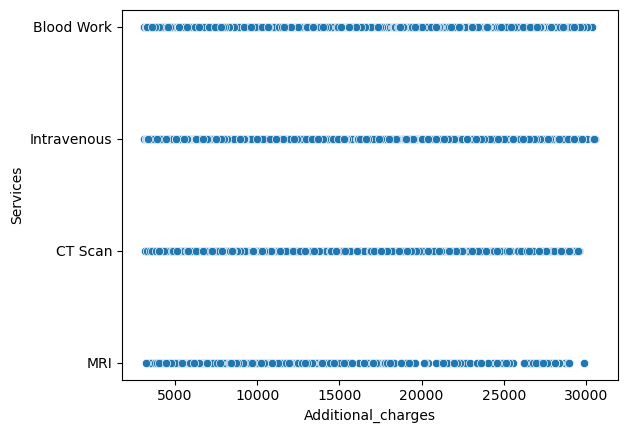

In [17]:
for independent in independent_targets_cat.columns:
    sns.scatterplot(x=dependent_target, y=independent, data=df)
    plt.show()

<a id='#PartC4'></a>
## C4: Data Transformation (Data Wrangling)

To prepare the medical dataset for a multiple linear regression model implementation, I will perform the following data wrangling activities:
- Identify and drop high cardinaility attributes from the dataset by using  `.nunique()` and `.drop` pandas methods.
- Encoding the following categorical variables (one-hot encoding, label encoding)
- Feature Engineering

In [18]:
try:
    # Identify columns that can be converted all at once to category datatype using for loop.
    category_cols = df[[ 'TimeZone', 'Marital', 'Gender', 'Overweight', 'Anxiety',  'Initial_admin', 'Complication_risk', 'Services', 'ReAdmis',
                             'Soft_drink', 'HighBlood', 'Stroke', 'Arthritis', 'Diabetes', 'Hyperlipidemia', 'BackPain',
                             'Allergic_rhinitis', 'Reflux_esophagitis', 'Asthma', 'Item1', 'Item2', 'Item3', 'Item4', 'Item5', 'Item6', 'Item7', 'Item8']]
    
    # Will do Item# columns later since they require an order. Timezone and Gender need a dict written, will do that later too.
    for col in category_cols:
        df[col] = df[col].astype('category')
        
    # re-express binary-liked categorical variables converted to numerical
    col_to_rexpress = ['ReAdmis', 'Soft_drink', 'HighBlood', 'Stroke',
                       'Overweight', 'Arthritis', 'Diabetes', 'Hyperlipidemia',
                       'BackPain', 'Anxiety', 'Allergic_rhinitis', 'Reflux_esophagitis',
                       'Asthma']
    
    for column in col_to_rexpress:
        df[f'Dummy_{column}'] = df[column].map({'Yes': 1, 'No': 0}).astype(np.int64)
    
    
    # re-express ordinal categorical variables with low cardinality 
    df['dummy_complication_risk'] = df['Complication_risk'].map({'Low': 1, 'Medium': 2, 'High': 3}).astype(np.int64)
    
    # re-express nominal categorical variables with low cardinality 
    df['dummy_initial_admin'] = df['Initial_admin'].map({'Emergency Admission': 0, 'Elective Admission': 1, 'Observation Admission': 2}).astype(np.int64)
    df['dummy_services'] = df['Services'].map({'Blood Work': 0, 'Intravenous': 1, 'CT Scan': 2, 'MRI': 3}).astype(np.int64)
    df['dummy_gender'] = df['Gender'].map({'Male': 0, 'Female' : 1, 'Nonbinary': 2}).astype(np.int64)
    
    
    
    # Remove obvious attributes with High Cardinality to reduce the risk of over-fitting the Regressuion model
    removal_attributes =['CaseOrder', 'Customer_id', 'Interaction', 'UID',
                          'Zip', 'Lat', 'Lng', 'City', 'State', 'County',
                          'Area', 'Job', 'Population']
    
    df = df.drop(columns=removal_attributes)
    
    # Remove attributes with 5 or more unique values
    categorical_medical_data = df[category_cols.columns]
    high_cardinalities = categorical_medical_data.nunique() > 4 #(> 3-5 Levels)
    high_cardinalities = high_cardinalities[high_cardinalities == True]
    high_cardinalities = list(high_cardinalities.index.values)
    print(f"High Cardinality attribute to be removed. \n{line_break}\n{high_cardinalities}\n {line_break} \n")
    df = df.drop(columns=high_cardinalities)
    
    #
    prepared_medical_clean = df.drop(columns=df.select_dtypes(include='category').columns)
except:
    print('An error has occurred')

High Cardinality attribute to be removed. 


['TimeZone', 'Marital', 'Item1', 'Item2', 'Item3', 'Item4', 'Item5', 'Item6', 'Item7', 'Item8']
 
 



In [19]:
low_cardinalities = [item for item in list((col_to_rexpress)) if item not in high_cardinalities]
print('Categoricals remaining:')
print(low_cardinalities)
print('\n')

# Generate column names which are pythonic in syntax and descriptive
pythonic_columns = ["children" ,"age", "income", "vitamin_d_level", "dr_visits", "full_meals", "vit_d_supp", "initial_stay", "daily_charge", "addl_charge", 
                    'Dummy_ReAdmis','Dummy_Soft_drink','Dummy_HighBlood',
                    'Dummy_Stroke','Dummy_Overweight','Dummy_Arthritis','Dummy_Diabetes','Dummy_Hyperlipidemia','Dummy_BackPain',
                    'Dummy_Anxiety','Dummy_Allergic_rhinitis','Dummy_Reflux_esophagitis','Dummy_Asthma','dummy_complication_risk',
                    'dummy_initial_admin','dummy_services','dummy_gender']

# Implement new pythonic column headings
prepared_medical_clean = prepared_medical_clean.set_axis(pythonic_columns, axis=1, copy=False)

Categoricals remaining:
['ReAdmis', 'Soft_drink', 'HighBlood', 'Stroke', 'Overweight', 'Arthritis', 'Diabetes', 'Hyperlipidemia', 'BackPain', 'Anxiety', 'Allergic_rhinitis', 'Reflux_esophagitis', 'Asthma']




In [20]:
prepared_medical_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   children                  10000 non-null  int64  
 1   age                       10000 non-null  int64  
 2   income                    10000 non-null  float64
 3   vitamin_d_level           10000 non-null  float64
 4   dr_visits                 10000 non-null  int64  
 5   full_meals                10000 non-null  int64  
 6   vit_d_supp                10000 non-null  int64  
 7   initial_stay              10000 non-null  float64
 8   daily_charge              10000 non-null  float64
 9   addl_charge               10000 non-null  float64
 10  Dummy_ReAdmis             10000 non-null  int64  
 11  Dummy_Soft_drink          10000 non-null  int64  
 12  Dummy_HighBlood           10000 non-null  int64  
 13  Dummy_Stroke              10000 non-null  int64  
 14  Dummy_O

<a id='#PartC5'></a> 

## C5: Copy of Prepared Data Set

In [21]:
prepared_medical_clean.to_csv('./initial-medical-model-dataset.csv')

<a id='#PartD1'></a>

## D1. Initial Model


In [22]:
#Update dependent variable value
dependent_target = 'addl_charge'

#Setting the value for X and Y
x = prepared_medical_clean.drop(columns=dependent_target)
y = prepared_medical_clean[dependent_target]

# Storing initial independent variables
x_initial_model = x.copy() 



In [23]:
def calculate_model(independent_target,dependent_targets):
    
    # Split our data arrays into two subsets: training and testing.
    x_train, x_test, y_train, y_test = train_test_split(independent_target,dependent_targets, test_size= 0.3, random_state = 100) 

    x_train = add_constant(x_train)

    # Create an instance of Linear regression to fit the mlr model
   # mlr = LinearRegression()
   # mlr_fit = mlr.fit(x_train, y_train)
    
    #OLS model 
    ols_fit = OLS(y_train, x_train).fit()

    #return x_train, y_train, mlr_fit, and ols_fit
    return ols_fit
    
def display_model_summary(ols_model_fitted):  
    
    # Display Intercept and Coefficient
    # print(f"\n Intercept: {mlr_model_fitted.intercept_} \n Coefficients: \n {list(zip(x, mlr_model_fitted.coef_))}\n")
    print(ols_model_fitted.summary())

ols_fit = calculate_model(x,y)
initial_model = display_model_summary(ols_fit)

                            OLS Regression Results                            
Dep. Variable:            addl_charge   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                     4081.
Date:                Thu, 04 Apr 2024   Prob (F-statistic):               0.00
Time:                        20:17:46   Log-Likelihood:                -61684.
No. Observations:                7000   AIC:                         1.234e+05
Df Residuals:                    6973   BIC:                         1.236e+05
Df Model:                          26                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                   

In [24]:
# Split our data arrays into two subsets, training and testing.
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size= 0.3, random_state = 100) 

# Create an instance of Linear regression to fit to mlr model
mlr = LinearRegression()
mlr_fit = mlr.fit(x_train, y_train)

x_train = add_constant(x_train)

#OLS 
intial_model = OLS(y_train, x_train).fit()

In [25]:
#Display Intercept and Coefficient
print(f"Intercept: {mlr.intercept_} \n Cofficients: \n {list(zip(x, mlr.coef_))}\n")
print(intial_model.summary())

Intercept: -4425.4824607509 
 Cofficients: 
 [('children', 22.86778881490375), ('age', 226.27421229281254), ('income', -0.0002277311447855991), ('vitamin_d_level', 0.44696941867330797), ('dr_visits', -27.86621776577432), ('full_meals', -1.8122957921365315), ('vit_d_supp', -16.13183054615602), ('initial_stay', -64.21260011661958), ('daily_charge', 0.7511228194972547), ('Dummy_ReAdmis', 111.80068329063313), ('Dummy_Soft_drink', 43.40634504311213), ('Dummy_HighBlood', 8508.696532726208), ('Dummy_Stroke', 352.35931012697216), ('Dummy_Overweight', 34.03319439142431), ('Dummy_Arthritis', -148.8704171967114), ('Dummy_Diabetes', -8.543126223435339), ('Dummy_Hyperlipidemia', -67.25086363579491), ('Dummy_BackPain', -93.42133327254247), ('Dummy_Anxiety', -39.08583674926096), ('Dummy_Allergic_rhinitis', -30.076087783009978), ('Dummy_Reflux_esophagitis', -29.86599937261285), ('Dummy_Asthma', 49.39200950525588), ('dummy_complication_risk', 92.2352808005587), ('dummy_initial_admin', -85.0185087965418

<a id='#PartD2'></a>

## D2. Model Reduction Method and Justification

•

We must check for multicollinearity before choosing a method to reduce the model. As previously stated, retaining multicollinear variables violates an assumption of multiple linear regression, leading to an unreliable model. Thus, I will use the variance inflation factor (VIF) below to check for multicollinearity between the initial model's variables. Explanatory variables with VIF > 10 will be investigated and omitted one at a time before true model reduction. When all explanatory variables have a VIF < 10, I can proceed to model reduction as this indicates multicollinearity that is too high to be acceptable has been eliminated.

* Discuss and describe what statistically based feature selection procedure or a model metric procedure you will use to reduce the initial model in a way that aligns with the research question. (Hint: Discussions regarding model reduction methods can be found in Getting Started with D208 Part I). (*)
* 
•	Explain (justify) why this method is being used to reduce your model.   


In [26]:
# Check VIF and remove variable with highest value VIF until all variables have VIF under 10.
# First, isolate explanatory variables.

def calculate_vif(df):
    ouput_statement: list = []
    VIF_df = pd.DataFrame()
    VIF_df['feature'] = df.columns
    VIF_df['VIF'] = [variance_inflation_factor(df.values,i) for i in range(len(df.columns))]
    return VIF_df.sort_values('VIF', ascending=False)
    
VIF_df = calculate_vif(x)
VIF_df

,feature,VIF
8,daily_charge,646.756047
7,initial_stay,266.466446
3,vitamin_d_level,60.321473
4,dr_visits,22.571621
22,dummy_complication_risk,16.820466
1,age,7.591755
9,Dummy_ReAdmis,5.735999
23,dummy_initial_admin,3.473779
13,Dummy_Overweight,3.420161
2,income,3.003438


In [27]:
def get_high_vif(df):
    return df.query('VIF > 10').sort_values('VIF', ascending=False).iloc[:,0].tolist()


In [28]:
# Let's dummy_complication_risk, dr_visits, vitamin_d_level, initial_stay, and daily_charge as they all have a VIF > 10.
high_vif = get_high_vif(VIF_df)

feature_list = []

while len(high_vif) > 0:
    try:
        feature_list.append(high_vif[0])
        x_high_vif_removed = x.drop(columns=feature_list)
        print(f'Removed the following feature(s): {feature_list[::]}\n{line_break}')   
    except (NameError):
        print(f'The following feature were not found dataframe x: {high_vif} {line_break}')
    
    x_high_vif_removed.info()
    print(line_break)

    # And then let's rerun this VIF check.
    x_high_vif_removed = calculate_vif(x_high_vif_removed)

    # update high_vif dataframe with latest VIF check
    high_vif = get_high_vif(x_high_vif_removed)

    # Display result
    print(f'\n {x_high_vif_removed}{line_break*2}')
    
print('All features remaining in our dataset have an VIF value less than 10.')


Removed the following feature(s): ['daily_charge']


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   children                  10000 non-null  int64  
 1   age                       10000 non-null  int64  
 2   income                    10000 non-null  float64
 3   vitamin_d_level           10000 non-null  float64
 4   dr_visits                 10000 non-null  int64  
 5   full_meals                10000 non-null  int64  
 6   vit_d_supp                10000 non-null  int64  
 7   initial_stay              10000 non-null  float64
 8   Dummy_ReAdmis             10000 non-null  int64  
 9   Dummy_Soft_drink          10000 non-null  int64  
 10  Dummy_HighBlood           10000 non-null  int64  
 11  Dummy_Stroke              10000 non-null  int64  
 12  Dummy_Overweight          10000 non-null  int64  
 13  Dummy_Art

<a id='#PartD3'></a>

## D3. Reduced Multiple Regression Model
With `daily_charge`, `vitamin_d_level`, `dr_visits` removed, we have successfully removed any problematic multicollinearity.

To reduce my model, I will use backwards stepwise elimination. This process will remove explanatory variables that do not provide value to the model because they are not statistically significant and hence do not inform the answer to the research question. In layman's terms, the variables I am about to remove using the method below have little to no relationship with the response variable, length of hospitalization, and are virtually useless. Thus, we will want to remove these "garbage" explanatory variables.

Backwards stepwise elimination is an iterative process where we remove the least statistically significant explanatory variable based on p-value until all explanatory variables are statistically significant. As is custom, I will set the p-value threshold to 0.05. Anything below this threshold will be considered statistically significant, while anything above will not. In backwards stepwise elimination I will remove the explanatory variable with the highest p-value until all p-values are under the threshold of 0.05.

To do this, I will run the multiple linear regression model in the same way I ran it for my initial model, but this time I will remove the explanatory variables with multicollinearity issues. In my case, this was just one variable-- Doc_visits. I will use the `.summary()` to pick out the explanatory variable with the highest p-value, eliminate it, and run the model again without it until the process is complete, as detailed above.

In [29]:
x_initial_model = x.copy()
if dependent_target not in feature_list:
    feature_list
print(f"{dependent_target} already exist within feature_list {line_break}")

for feature in feature_list:
    try:
        x = x.drop(columns=[feature])
        print(f"{feature} removed from independent target list.")
    except(KeyError):
        print(f"{feature} was not found in axis")
        
    
   
y = prepared_medical_clean[dependent_target]

def calculate_model(independent_target,dependent_targets):
    # Split our data arrays into two subsets: training and testing.
    x_train, x_test, y_train, y_test = train_test_split(independent_target,dependent_targets, test_size= 0.3, random_state = 100) 

    
    x_train = add_constant(x_train)

    
    # Create an instance of Linear regression to fit the mlr model
   # mlr = LinearRegression()
   # mlr_fit = mlr.fit(x_train, y_train)
    
    #OLS model 
    ols_fit = OLS(y_train, x_train).fit()

    #return x_train, y_train, mlr_fit, and ols_fit
    return ols_fit, mlr_fit
    
def display_model_summary(ols_model_fitted, mlr_model_fitted):  
    #Display Intercept and Coefficient
    print(f"\n Intercept: {mlr_model_fitted.intercept_} \n Coefficients: \n {list(zip(x, mlr_model_fitted.coef_))}\n")
    print(ols_model_fitted.summary())

ols_fit, mlr_fit = calculate_model(x,y)
BSE1_model = display_model_summary(ols_fit, mlr_fit)

addl_charge already exist within feature_list 

daily_charge removed from independent target list.
vitamin_d_level removed from independent target list.
dr_visits removed from independent target list.

 Intercept: -4425.4824607509 
 Coefficients: 
 [('children', 22.86778881490375), ('age', 226.27421229281254), ('income', -0.0002277311447855991), ('full_meals', 0.44696941867330797), ('vit_d_supp', -27.86621776577432), ('initial_stay', -1.8122957921365315), ('Dummy_ReAdmis', -16.13183054615602), ('Dummy_Soft_drink', -64.21260011661958), ('Dummy_HighBlood', 0.7511228194972547), ('Dummy_Stroke', 111.80068329063313), ('Dummy_Overweight', 43.40634504311213), ('Dummy_Arthritis', 8508.696532726208), ('Dummy_Diabetes', 352.35931012697216), ('Dummy_Hyperlipidemia', 34.03319439142431), ('Dummy_BackPain', -148.8704171967114), ('Dummy_Anxiety', -8.543126223435339), ('Dummy_Allergic_rhinitis', -67.25086363579491), ('Dummy_Reflux_esophagitis', -93.42133327254247), ('Dummy_Asthma', -39.08583674926096)

In [30]:
# Remove children
x=x.drop(columns='children')
ols_fit, mlr_fit = calculate_model(x,y)
BSE2_model = display_model_summary(ols_fit, mlr_fit)


 Intercept: -4425.4824607509 
 Coefficients: 
 [('age', 22.86778881490375), ('income', 226.27421229281254), ('full_meals', -0.0002277311447855991), ('vit_d_supp', 0.44696941867330797), ('initial_stay', -27.86621776577432), ('Dummy_ReAdmis', -1.8122957921365315), ('Dummy_Soft_drink', -16.13183054615602), ('Dummy_HighBlood', -64.21260011661958), ('Dummy_Stroke', 0.7511228194972547), ('Dummy_Overweight', 111.80068329063313), ('Dummy_Arthritis', 43.40634504311213), ('Dummy_Diabetes', 8508.696532726208), ('Dummy_Hyperlipidemia', 352.35931012697216), ('Dummy_BackPain', 34.03319439142431), ('Dummy_Anxiety', -148.8704171967114), ('Dummy_Allergic_rhinitis', -8.543126223435339), ('Dummy_Reflux_esophagitis', -67.25086363579491), ('Dummy_Asthma', -93.42133327254247), ('dummy_complication_risk', -39.08583674926096), ('dummy_initial_admin', -30.076087783009978), ('dummy_services', -29.86599937261285), ('dummy_gender', 49.39200950525588)]

                            OLS Regression Results          

In [31]:
# Remove Dummy_Anxiety              
x=x.drop(columns='Dummy_Anxiety')
ols_fit, mlr_fit = calculate_model(x,y)
BSE3_model = display_model_summary(ols_fit, mlr_fit)


 Intercept: -4425.4824607509 
 Coefficients: 
 [('age', 22.86778881490375), ('income', 226.27421229281254), ('full_meals', -0.0002277311447855991), ('vit_d_supp', 0.44696941867330797), ('initial_stay', -27.86621776577432), ('Dummy_ReAdmis', -1.8122957921365315), ('Dummy_Soft_drink', -16.13183054615602), ('Dummy_HighBlood', -64.21260011661958), ('Dummy_Stroke', 0.7511228194972547), ('Dummy_Overweight', 111.80068329063313), ('Dummy_Arthritis', 43.40634504311213), ('Dummy_Diabetes', 8508.696532726208), ('Dummy_Hyperlipidemia', 352.35931012697216), ('Dummy_BackPain', 34.03319439142431), ('Dummy_Allergic_rhinitis', -148.8704171967114), ('Dummy_Reflux_esophagitis', -8.543126223435339), ('Dummy_Asthma', -67.25086363579491), ('dummy_complication_risk', -93.42133327254247), ('dummy_initial_admin', -39.08583674926096), ('dummy_services', -30.076087783009978), ('dummy_gender', -29.86599937261285)]

                            OLS Regression Results                            
Dep. Variable:     

In [32]:
# Remove Dummy_Asthma              
x=x.drop(columns='Dummy_Asthma')
ols_fit, mlr_fit = calculate_model(x,y)
BSE4_model = display_model_summary(ols_fit, mlr_fit)


 Intercept: -4425.4824607509 
 Coefficients: 
 [('age', 22.86778881490375), ('income', 226.27421229281254), ('full_meals', -0.0002277311447855991), ('vit_d_supp', 0.44696941867330797), ('initial_stay', -27.86621776577432), ('Dummy_ReAdmis', -1.8122957921365315), ('Dummy_Soft_drink', -16.13183054615602), ('Dummy_HighBlood', -64.21260011661958), ('Dummy_Stroke', 0.7511228194972547), ('Dummy_Overweight', 111.80068329063313), ('Dummy_Arthritis', 43.40634504311213), ('Dummy_Diabetes', 8508.696532726208), ('Dummy_Hyperlipidemia', 352.35931012697216), ('Dummy_BackPain', 34.03319439142431), ('Dummy_Allergic_rhinitis', -148.8704171967114), ('Dummy_Reflux_esophagitis', -8.543126223435339), ('dummy_complication_risk', -67.25086363579491), ('dummy_initial_admin', -93.42133327254247), ('dummy_services', -39.08583674926096), ('dummy_gender', -30.076087783009978)]

                            OLS Regression Results                            
Dep. Variable:            addl_charge   R-squared:       

In [33]:
# Remove Dummy_Soft_drink                         
x=x.drop(columns='Dummy_Soft_drink')
ols_fit, mlr_fit = calculate_model(x,y)
BSE5_model = display_model_summary(ols_fit, mlr_fit)


 Intercept: -4425.4824607509 
 Coefficients: 
 [('age', 22.86778881490375), ('income', 226.27421229281254), ('full_meals', -0.0002277311447855991), ('vit_d_supp', 0.44696941867330797), ('initial_stay', -27.86621776577432), ('Dummy_ReAdmis', -1.8122957921365315), ('Dummy_HighBlood', -16.13183054615602), ('Dummy_Stroke', -64.21260011661958), ('Dummy_Overweight', 0.7511228194972547), ('Dummy_Arthritis', 111.80068329063313), ('Dummy_Diabetes', 43.40634504311213), ('Dummy_Hyperlipidemia', 8508.696532726208), ('Dummy_BackPain', 352.35931012697216), ('Dummy_Allergic_rhinitis', 34.03319439142431), ('Dummy_Reflux_esophagitis', -148.8704171967114), ('dummy_complication_risk', -8.543126223435339), ('dummy_initial_admin', -67.25086363579491), ('dummy_services', -93.42133327254247), ('dummy_gender', -39.08583674926096)]

                            OLS Regression Results                            
Dep. Variable:            addl_charge   R-squared:                       0.938
Model:               

In [34]:
# Remove income
x=x.drop(columns='income')
ols_fit, mlr_fit = calculate_model(x,y)
BSE6_model = display_model_summary(ols_fit, mlr_fit)


 Intercept: -4425.4824607509 
 Coefficients: 
 [('age', 22.86778881490375), ('full_meals', 226.27421229281254), ('vit_d_supp', -0.0002277311447855991), ('initial_stay', 0.44696941867330797), ('Dummy_ReAdmis', -27.86621776577432), ('Dummy_HighBlood', -1.8122957921365315), ('Dummy_Stroke', -16.13183054615602), ('Dummy_Overweight', -64.21260011661958), ('Dummy_Arthritis', 0.7511228194972547), ('Dummy_Diabetes', 111.80068329063313), ('Dummy_Hyperlipidemia', 43.40634504311213), ('Dummy_BackPain', 8508.696532726208), ('Dummy_Allergic_rhinitis', 352.35931012697216), ('Dummy_Reflux_esophagitis', 34.03319439142431), ('dummy_complication_risk', -148.8704171967114), ('dummy_initial_admin', -8.543126223435339), ('dummy_services', -67.25086363579491), ('dummy_gender', -93.42133327254247)]

                            OLS Regression Results                            
Dep. Variable:            addl_charge   R-squared:                       0.938
Model:                            OLS   Adj. R-square

In [35]:
# Remove dummy_complication_risk
x=x.drop(columns='dummy_complication_risk')
ols_fit, mlr_fit = calculate_model(x,y)
BSE7_model = display_model_summary(ols_fit, mlr_fit)


 Intercept: -4425.4824607509 
 Coefficients: 
 [('age', 22.86778881490375), ('full_meals', 226.27421229281254), ('vit_d_supp', -0.0002277311447855991), ('initial_stay', 0.44696941867330797), ('Dummy_ReAdmis', -27.86621776577432), ('Dummy_HighBlood', -1.8122957921365315), ('Dummy_Stroke', -16.13183054615602), ('Dummy_Overweight', -64.21260011661958), ('Dummy_Arthritis', 0.7511228194972547), ('Dummy_Diabetes', 111.80068329063313), ('Dummy_Hyperlipidemia', 43.40634504311213), ('Dummy_BackPain', 8508.696532726208), ('Dummy_Allergic_rhinitis', 352.35931012697216), ('Dummy_Reflux_esophagitis', 34.03319439142431), ('dummy_initial_admin', -148.8704171967114), ('dummy_services', -8.543126223435339), ('dummy_gender', -67.25086363579491)]

                            OLS Regression Results                            
Dep. Variable:            addl_charge   R-squared:                       0.937
Model:                            OLS   Adj. R-squared:                  0.937
Method:                

In [36]:
# Remove income
x=x.drop(columns='Dummy_Diabetes')
BSE8_model, mlr_fit = calculate_model(x,y)
display_model_summary(BSE8_model, mlr_fit)


 Intercept: -4425.4824607509 
 Coefficients: 
 [('age', 22.86778881490375), ('full_meals', 226.27421229281254), ('vit_d_supp', -0.0002277311447855991), ('initial_stay', 0.44696941867330797), ('Dummy_ReAdmis', -27.86621776577432), ('Dummy_HighBlood', -1.8122957921365315), ('Dummy_Stroke', -16.13183054615602), ('Dummy_Overweight', -64.21260011661958), ('Dummy_Arthritis', 0.7511228194972547), ('Dummy_Hyperlipidemia', 111.80068329063313), ('Dummy_BackPain', 43.40634504311213), ('Dummy_Allergic_rhinitis', 8508.696532726208), ('Dummy_Reflux_esophagitis', 352.35931012697216), ('dummy_initial_admin', 34.03319439142431), ('dummy_services', -148.8704171967114), ('dummy_gender', -8.543126223435339)]

                            OLS Regression Results                            
Dep. Variable:            addl_charge   R-squared:                       0.937
Model:                            OLS   Adj. R-squared:                  0.937
Method:                 Least Squares   F-statistic:           

The last model, directly above, is my reduced model and my final model. Every variable has a p-value, indicated in the 5th column of the table, that is below 0.05. Thus, all of the remaining explanatory variables in the model are statistically significant. I will reiterate this below.

<a id='#PartE1'></a>

## E1. Model Comparison 
I will use the adjusted r-squared value as my evaluation metric to compare my initial and reduced models. R-squared, also known as the coefficient of determination, tells us how much of the variance in the response variable, the amount of additional charge, can be predicted by the explanatory variables. However, as you include more explanatory variables, this model evaluation metric inevitably continues to increase, even if there is little improvement in adding more explanatory variables. Thus, it is preferable to use adjusted r-squared, which is why I have chosen it over r-squared. With multiple explanatory variables, I prefer a metric that penalizes each explanatory variable added. In this case, whether I choose r-squared or adjusted r-squared, the values of these metrics for my reduced model are the same. However, it is important to note that using adjusted r-squared for model evaluation is generally better than r-squared for multiple linear regression. A model with a higher adjusted r-squared is a better model.



In [37]:
print(f'Initial model adjusted, r-sq: {round(intial_model.rsquared_adj, 5)}')
print(f'Reduced model adjusted, r-sq: {round(BSE8_model.rsquared_adj, 5)}')

Initial model adjusted, r-sq: 0.93811
Reduced model adjusted, r-sq: 0.93697


<a id='#PartE2'></a>

## E2. Multiple Linear Regression (Task 1) 




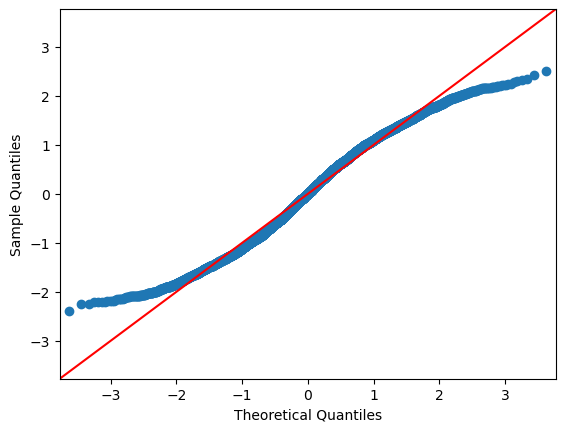

In [38]:
qqplot(data=BSE8_model.resid, fit=True, line='45')
plt.show()

Ideally, the plot above should show the blue dots closely following the red reference line. The more closely they follow this line, the better the model's fit. A "perfect" model that follows the red line exactly indicates the model's residuals are normally distributed. The curviness of the line of blue dots in the above graph indicates that the reduced model's fit could be improved as its residuals are not normally distributed.

In [39]:
RSE_reduced = np.sqrt(BSE8_model.mse_resid)
print(f'Reduced model RSE: ${round(RSE_reduced, 2)} USD')

Reduced model RSE: $1642.77 USD


<a id='#PartE3'></a>
## E3. Code
The attached .ipynb file contains all the code used for cleaning, transformation, exploration, and the linear models. Please utilize this file as the executable code required by this section.


<a id='#PartF1'></a>

## F1. Regression Equation, Coefficients, etc

In [40]:
BSE8_model.summary2().tables[1]['Coef.']
# Reduced regression equation 
ŷ = 17.535854(additional_charge) + 46.469335(readmission) - 1.483961(emergency admission) + 1.151676(complication risk low) - 1.006527(CT scan service)

print(f'ŷ = {} ({dependent_target}) ')

# Reduced model interpretation of the coefficients



SyntaxError: invalid syntax. Perhaps you forgot a comma? (1107023050.py, line 3)

### Discussion regarding the statistical significance and practical significance 
Placeholder

<a id='#PartF2'></a>

## F2. Recommendations

Placeholder

<a id='#PartG'></a>

## G. Panopto Recording

PLaceholder

<a id='#PartH'></a>

## H. Code References

Baker, B. (2023, December 16). D206: Data Cleaning Performance Assessment. Unpublished manuscript, Western Governors University.



<a id='#PartI'></a>

## I. Source References
Placeholder

1. https://www.statisticssolutions.com/free-resources/directory-of-statistical-analyses/assumptions-of-multiple-linear-regression/
2. https://www.investopedia.com/terms/m/mlr.asp#:~:text=Key%20Takeaways-,Multiple%20linear%20regression%20(MLR)%2C%20also%20known%20simply%20as%20multiple,uses%20just%20one%20explanatory%20variable.

